## Draw the Player Bullets

In [194]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

### Generate Level Diagrams with a Grid Overlay

In [1]:
def getDreadnoughtData(level_data_lines):
    raw_dreadnought_data = [l[14:].strip() for l in level_data_lines]
    dreadnought_data = [x for l in raw_dreadnought_data for x in l.split(',')]

    end_of_base_data = dreadnought_data.index('$00')
    base_data = [x[1:] for x in dreadnought_data[:end_of_base_data]]
    raw_location_data = dreadnought_data[end_of_base_data+1:]
    location_data = []
    for i in range(0, len(raw_location_data), 3):
        hi_byte = int(raw_location_data[i][1:],16)
        if not hi_byte:
            break
        hi_byte |= 0x80
        hi_byte &= 0xBF
        hi_byte = hex(hi_byte)[2:]
        lo_byte = raw_location_data[i+1][1:]
        hex_location = hi_byte + lo_byte
        location = int(hex_location,16)
        structure = raw_location_data[i+2][1:]
        location_data += [(hex_location, location,structure)]
    dreadnought_surface = (base_data,location_data)
    return dreadnought_surface

# Read in bulk of the dreadnought data from level data first.
level_data_file = "uridium/src/level_data.asm"
lines_in_file = open(level_data_file,'r').readlines()

dreadnought_surfaces = {}
level_data_lines = []
current_dreadnought = ""
for l in lines_in_file:
    if l.startswith("level") and "DreadnoughtData" in l:
        if current_dreadnought:
            dreadnought_surfaces[current_dreadnought] = getDreadnoughtData(level_data_lines)
        current_dreadnought = l[:22].strip()
        level_data_lines = []
    if ".BYTE" not in l:
        continue
    level_data_lines += [l]
dreadnought_surfaces[current_dreadnought] = getDreadnoughtData(level_data_lines)

# Read in remaining dreadnoughts from charset.asm
level_data_file = "uridium/src/charset.asm"
lines_in_file = open(level_data_file,'r').readlines()

assert "level7DreadnoughtData" in lines_in_file[1297]
level_data_lines = [l for l in lines_in_file[1298:1358] if ".BYTE" in l]
dreadnought_surfaces["level7DreadnoughtData"] = getDreadnoughtData(level_data_lines)

assert "level8DreadnoughtData" in lines_in_file[1358]
level_data_lines = [l for l in lines_in_file[1359:1425] if ".BYTE" in l]
dreadnought_surfaces["level8DreadnoughtData"] = getDreadnoughtData(level_data_lines)


In [30]:
from PIL import Image, ImageColor
import math

DREADNOUGHT_COLS = 0x200
LOCATION_START = 0x8200
LOCATION_END = 0xA400

test_image = Image.open(f"surface_character_set_diagrams/character_sets/1_00.png")
character_height = test_image.height
character_width = test_image.width

width = DREADNOUGHT_COLS * character_width # padding from diagram
height = int((LOCATION_END - LOCATION_START) / DREADNOUGHT_COLS) * character_height # 128

for LEVEL in range(1,16):
    base_data, location_data = dreadnought_surfaces[f"level{LEVEL}DreadnoughtData"]
    img = Image.new( 'RGBA', (width,height))

    x,y = 64 * character_width,0
    for structure in base_data:
        strip_image = Image.open(f"surface_character_set_diagrams/surface_strips_hex/{LEVEL}_{structure}_no_text.png")
        # Y position is relative to the bottom of the map.
        y = height - strip_image.height
        img.paste(strip_image,(x,y),mask=strip_image)
        
        x+= strip_image.width

    for hex_offset, location, structure in location_data:
        if structure == "20":
            print(structure)
        strip_image = Image.open(f"surface_character_set_diagrams/surface_structures_hex/{LEVEL}_{structure}_no_text.png")
        
        offset = location - LOCATION_START
        x = (offset % DREADNOUGHT_COLS) * character_width

        # The location given is for the bottom of the object (uridium draws upwards)
        y = (int(math.ceil(offset / DREADNOUGHT_COLS)) * character_height) - (strip_image.height - 10) # padding at bottom of diagram
        img.paste(strip_image,(x,y),mask=strip_image)

    img.save(f"bullets_player/surface_diagrams/{LEVEL}_no_text.png")


In [201]:
from PIL import Image, ImageColor
import math

DREADNOUGHT_COLS = 0x200
LOCATION_START = 0x8200
LOCATION_END = 0xA400

test_image = Image.open(f"surface_character_set_diagrams/character_sets/1_00.png")
character_height = test_image.height
character_width = test_image.width

width = DREADNOUGHT_COLS * character_width # padding from diagram
height = int((LOCATION_END - LOCATION_START) / DREADNOUGHT_COLS) * character_height # 128

for LEVEL in range(1,16):
    base_data, location_data = dreadnought_surfaces[f"level{LEVEL}DreadnoughtData"]
    img = Image.new( 'RGBA', (width,height))

    x,y = 64 * character_width,0
    for structure in base_data:
        strip_image = Image.open(f"surface_character_set_diagrams/surface_strips_hex/{LEVEL}_{structure}_no_text.png")
        # Y position is relative to the bottom of the map.
        y = height - strip_image.height
        img.paste(strip_image,(x,y),mask=strip_image)
        
        x+= strip_image.width

    for hex_offset, location, structure in location_data:
        if structure == "20":
            print(structure)
        strip_image = Image.open(f"surface_character_set_diagrams/surface_structures_destroyed_hex/{LEVEL}_{structure}_no_text.png")
        
        offset = location - LOCATION_START
        x = (offset % DREADNOUGHT_COLS) * character_width

        # The location given is for the bottom of the object (uridium draws upwards)
        y = (int(math.ceil(offset / DREADNOUGHT_COLS)) * character_height) - (strip_image.height - 10) # padding at bottom of diagram
        img.paste(strip_image,(x,y),mask=strip_image)

    img.save(f"bullets_player/surface_diagrams/{LEVEL}_destroyed_no_text.png")


In [210]:
from PIL import Image, ImageColor
import math

DREADNOUGHT_COLS = 0x200
LOCATION_START = 0x8200
LOCATION_END = 0xA400

test_image = Image.open(f"surface_character_set_diagrams/character_sets/1_00.png")
character_height = test_image.height
character_width = test_image.width

width = DREADNOUGHT_COLS * character_width # padding from diagram
height = int((LOCATION_END - LOCATION_START) / DREADNOUGHT_COLS) * character_height # 128

for LEVEL in range(1,16):
    base_data, location_data = dreadnought_surfaces[f"level{LEVEL}DreadnoughtData"]
    img = Image.new( 'RGBA', (width,height))

    x,y = 64 * character_width,0
    for structure in base_data:
        strip_image = Image.open(f"surface_character_set_diagrams/surface_strips_hex/{LEVEL}_{structure}_no_text.png")
        # Y position is relative to the bottom of the map.
        y = height - strip_image.height
        img.paste(strip_image,(x,y),mask=strip_image)
        
        x+= strip_image.width

    for hex_offset, location, structure in location_data:
        if structure == "20":
            print(structure)
        strip_image = Image.open(f"surface_character_set_diagrams/surface_structures_destroyed_hex/{LEVEL}_{structure}.png")
        
        offset = location - LOCATION_START
        x = (offset % DREADNOUGHT_COLS) * character_width

        # The location given is for the bottom of the object (uridium draws upwards)
        y = (int(math.ceil(offset / DREADNOUGHT_COLS)) * character_height) - (strip_image.height - 10) # padding at bottom of diagram
        img.paste(strip_image,(x,y),mask=strip_image)

    img.save(f"bullets_player/surface_diagrams/{LEVEL}_destroyed.png")


### Get the Manta Sprite

In [212]:
from PIL import Image

FACTOR = 15

def get_surface_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"bullets_player/surface_diagrams/{level}_no_text.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    #img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def get_destroyed_surface_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"bullets_player/surface_diagrams/{level}_destroyed_no_text.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    #img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def get_surface_character_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"surface_character_set_diagrams/surface_diagrams/{level}.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    #img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def get_destroyed_surface_character_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"bullets_player/surface_diagrams/{level}_destroyed.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    #img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def make_shadow(img, color=(0x4a, 0x4a, 0x4a, 255)):
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] == 0:
            new_image.append(item)
        else:
            new_image.append(color)
    # update image data
    img.putdata(new_image)
    return img

resize = lambda img,factor: img.resize((int(img.width * factor), int(img.height * factor)), Image.NEAREST)
add_offset = lambda a,b : [sum(x) for x in zip(a,b)]
scale = lambda x: x * FACTOR
cells = lambda x: x * 120



In [268]:
from PIL import Image, ImageDraw

img = Image.open("manta_spin_diagrams/MANTA1.png")
img = resize(img, FACTOR)
manta = img.copy()
shadow = make_shadow(img)

### Create a Bullet Image

In [128]:
from PIL import Image, ImageDraw

img = Image.new('RGBA', (8,2))
draw = ImageDraw.Draw(img)
draw.line((0,0,8,0), fill="white", width=1)
draw.line((0,1,8,1), fill=(0x4a, 0x4a, 0x4a, 255), width=1)
img = resize(img,FACTOR)
bullet = img

### Draw Bullet Progress Along the Surface

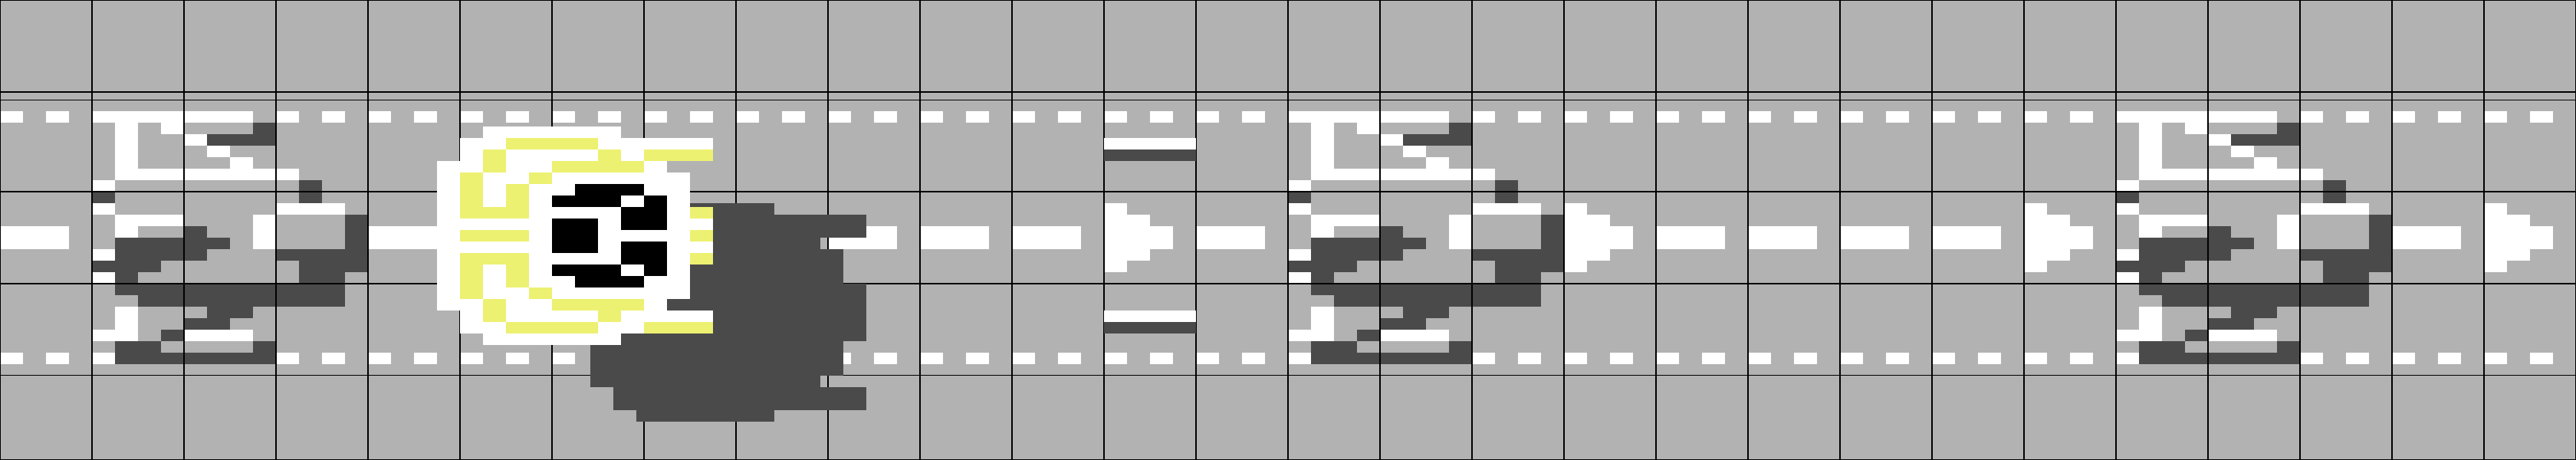

In [194]:
for bullet_x in range(64, 64 + 48, 16):
    diagram = get_surface_snippet(level=1, x_offset=scale(1024), y_offset = 120, width=scale(224), height = scale(40))
    manta_pos = (scale(38),scale(10))
    shadow_offset = (20*10,10*10)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)


    bullet_pos = (scale(bullet_x), scale(10) + 30)
    diagram.paste(bullet, bullet_pos, mask=bullet)
    bullet_pos = (scale(bullet_x), scale(25) + 30)
    diagram.paste(bullet, bullet_pos, mask=bullet)

    diagram.save(f"bullets_player/level1_bullet_progress_{bullet_x}.png")
diagram

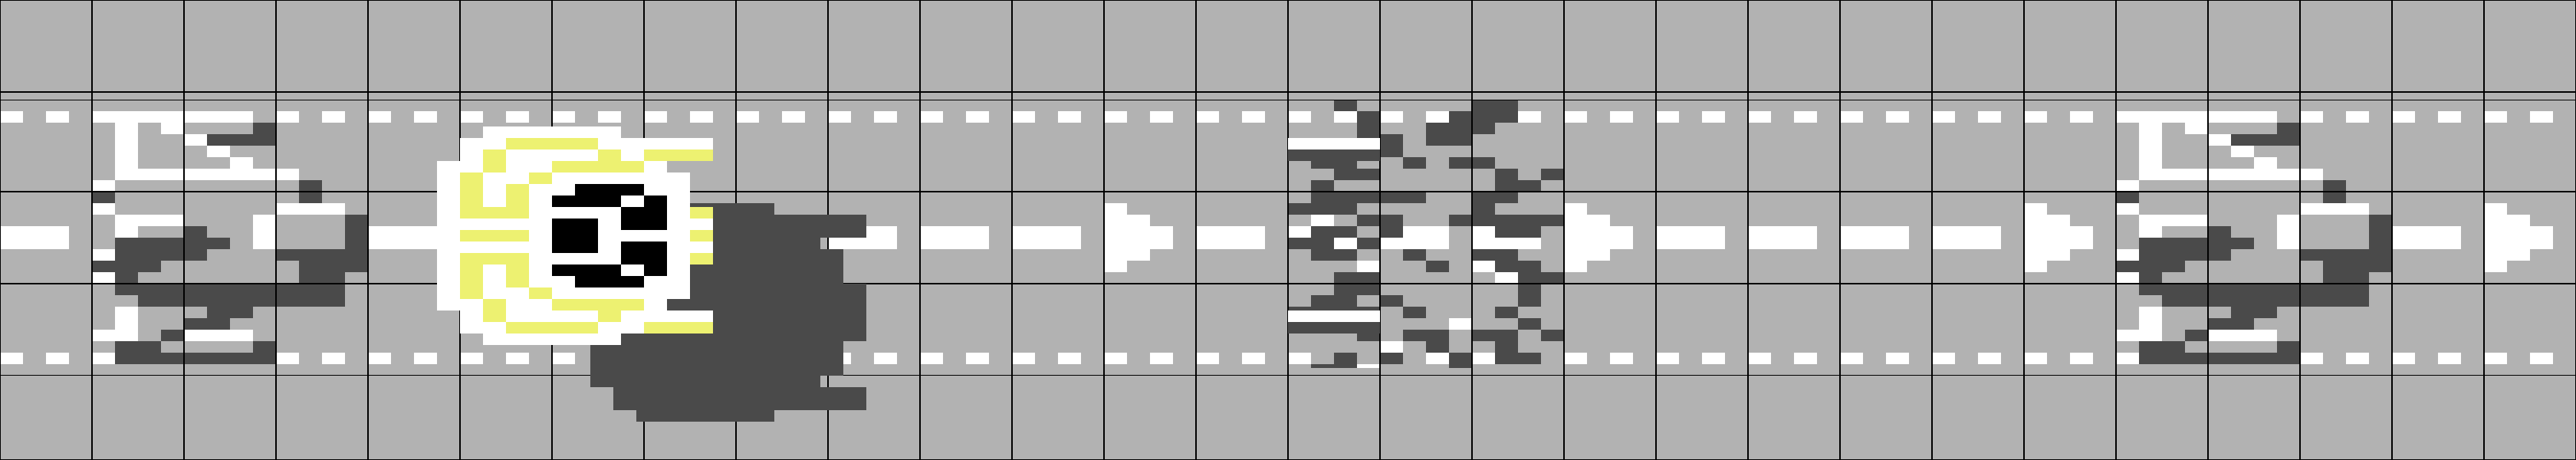

In [206]:
for bullet_x in range(64, 64 + 64, 16):
    diagram = get_surface_snippet(level=1, x_offset=scale(1024), y_offset = 120, width=scale(224), height = scale(40))
    
    destroyed_diagram = get_destroyed_surface_snippet(level=1, x_offset=scale(1024), y_offset = 120, width=scale(224), height = scale(40))
    destroyed_snippet = destroyed_diagram.crop((cells(13), cells(1), cells(17), cells(4)))
    diagram.paste(destroyed_snippet, (cells(13),cells(1)), mask=destroyed_snippet)

    manta_pos = (scale(38),scale(10))
    shadow_offset = (20*10,10*10)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)

    bullet_pos = (scale(bullet_x), scale(10) + 30)
    diagram.paste(bullet, bullet_pos, mask=bullet)
    bullet_pos = (scale(bullet_x), scale(25) + 30)
    diagram.paste(bullet, bullet_pos, mask=bullet)

    diagram.save(f"bullets_player/level1_destroyed_bullet_progress_{bullet_x}.png")
diagram

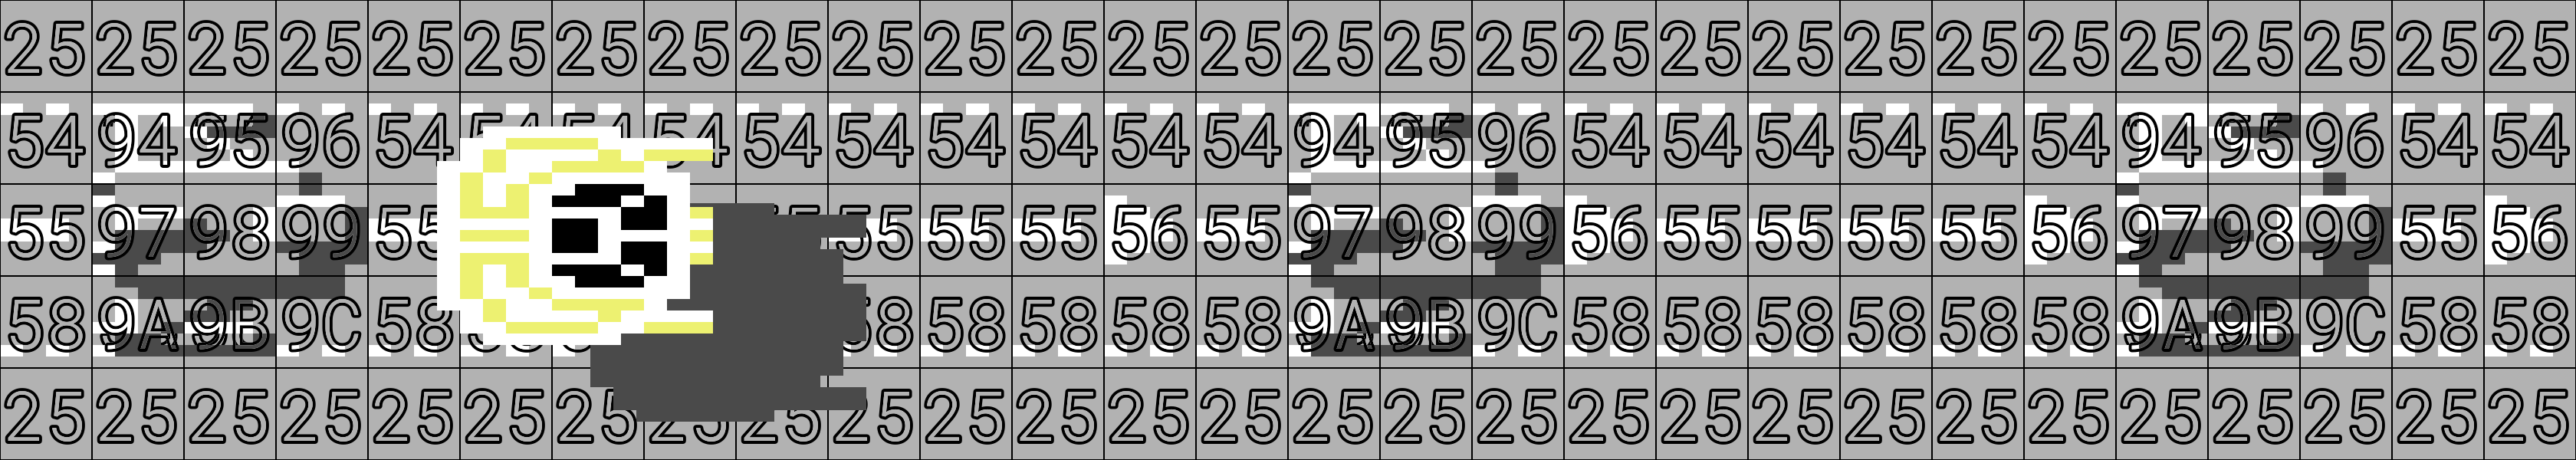

In [209]:
for bullet_x in range(64, 64 + 64, 16):
    diagram = get_surface_character_snippet(level=1, x_offset=scale(1024), y_offset = 120, width=scale(224), height = scale(40))
    
    manta_pos = (scale(38),scale(10))
    shadow_offset = (20*10,10*10)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)

    diagram.save(f"bullets_player/level1_characters_bullet_progress_{bullet_x}.png")
diagram

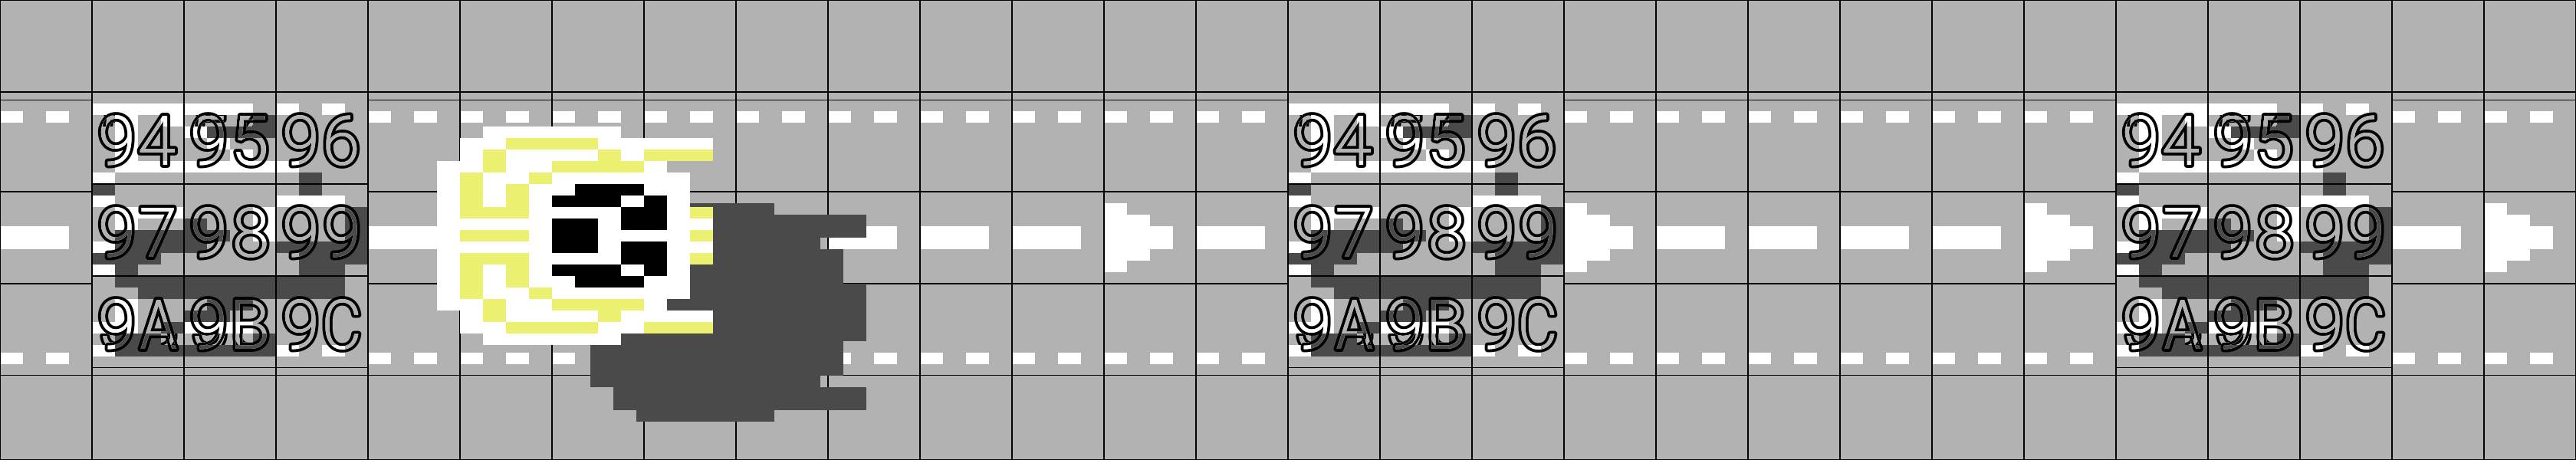

In [272]:
for bullet_x in range(64, 64 + 64, 16):
    diagram = get_surface_snippet(level=1, x_offset=scale(1024), y_offset = 120, width=scale(224), height = scale(40))
    
    destroyed_diagram = get_surface_character_snippet(level=1, x_offset=scale(1024), y_offset = 120, width=scale(224), height = scale(40))
    destroyed_snippet = destroyed_diagram.crop((cells(14), cells(1), cells(17), cells(4)))
    diagram.paste(destroyed_snippet, (cells(1),cells(1)), mask=destroyed_snippet)
    diagram.paste(destroyed_snippet, (cells(14),cells(1)), mask=destroyed_snippet)
    diagram.paste(destroyed_snippet, (cells(23),cells(1)), mask=destroyed_snippet)
    
    manta_pos = (scale(38),scale(10))
    shadow_offset = (20*10,10*10)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)

    diagram.save(f"bullets_player/level1_characters2_bullet_progress_{bullet_x}.png")
diagram

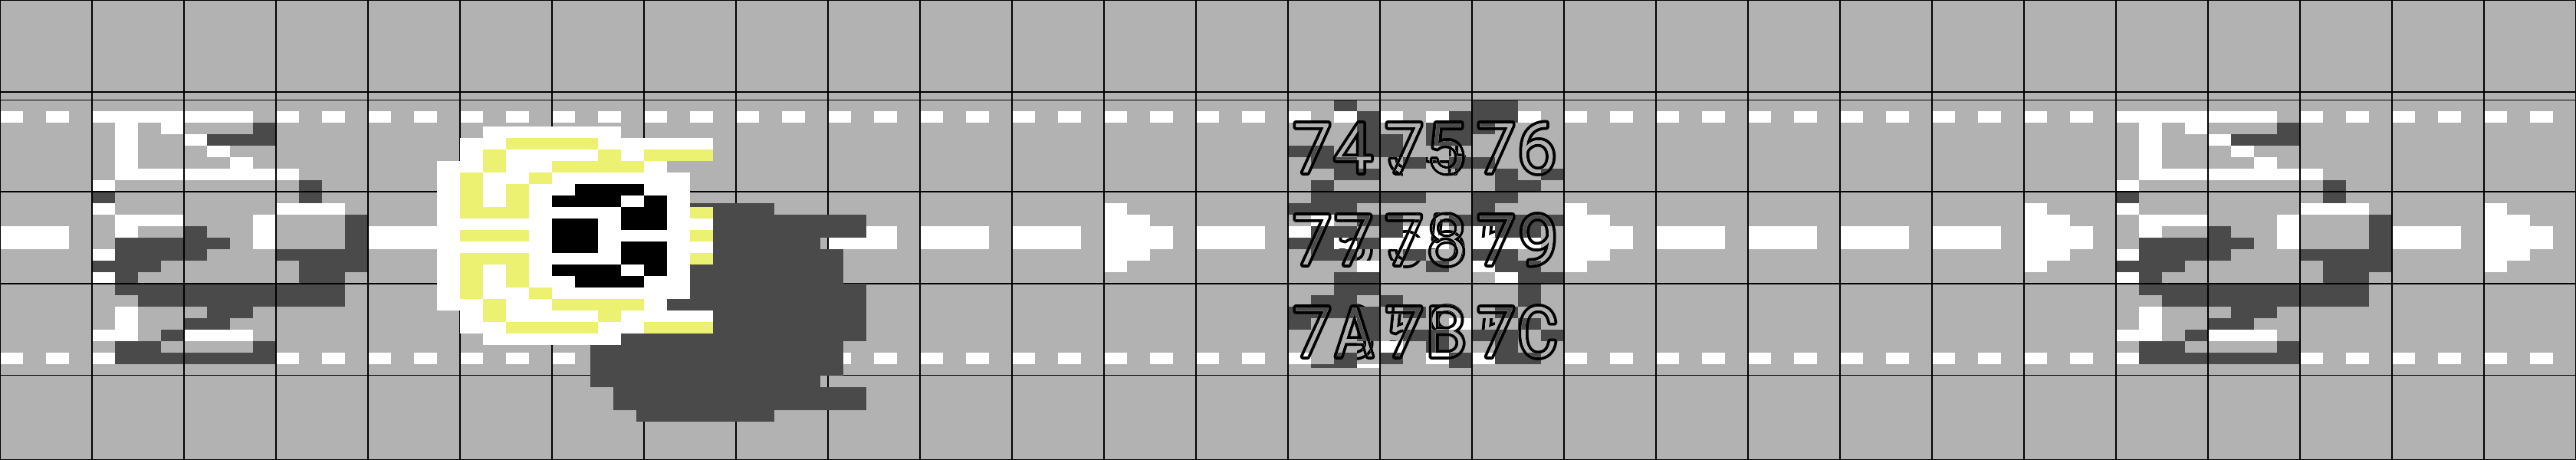

In [215]:
for bullet_x in range(64, 64 + 64, 16):
    diagram = get_surface_snippet(level=1, x_offset=scale(1024), y_offset = 120, width=scale(224), height = scale(40))
    
    destroyed_diagram = get_destroyed_surface_character_snippet(level=1, x_offset=scale(1024), y_offset = 120, width=scale(224), height = scale(40))
    destroyed_snippet = destroyed_diagram.crop((cells(14), cells(1), cells(17), cells(4)))
    diagram.paste(destroyed_snippet, (cells(14),cells(1)), mask=destroyed_snippet)

    manta_pos = (scale(38),scale(10))
    shadow_offset = (20*10,10*10)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)

    diagram.save(f"bullets_player/level1_destroyed_character_bullet_progress_{bullet_x}.png")
diagram

### Bullet Being Blocked

In [247]:
c64_to_rgb[level_colors[5][2]]

'#56ac4d'

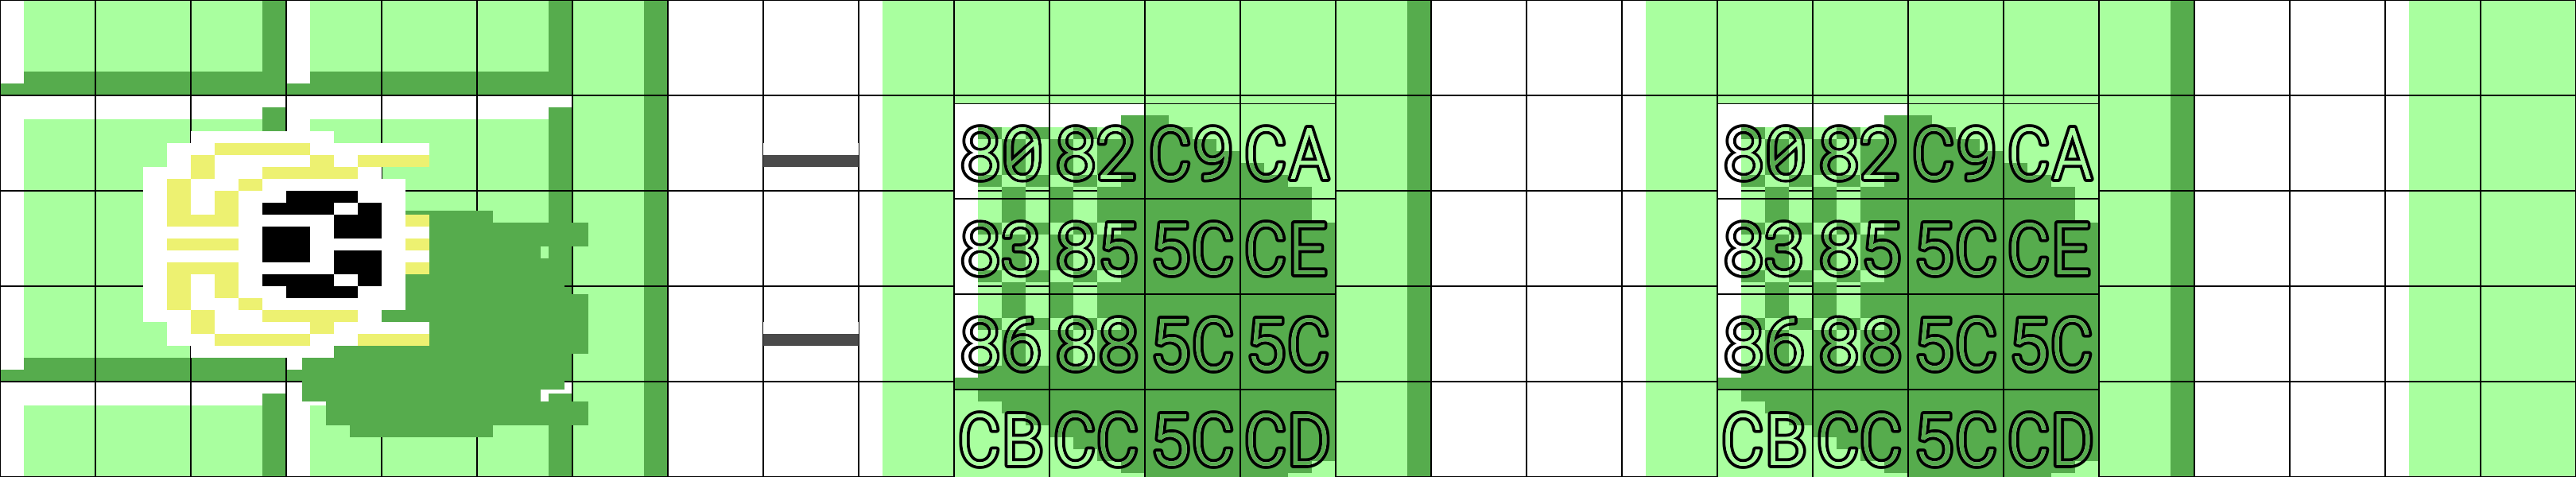

In [266]:
diagram = get_destroyed_surface_character_snippet(level=5, x_offset=cells(95), y_offset = 720, width=scale(216), height = scale(40))
shadow = make_shadow(manta.copy(), color=(0x56,0xac,0x4d,255))
manta_pos = (scale(12),scale(10))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)

bullet_x = cells(8)
bullet_pos = (bullet_x, scale(10) + 30)
diagram.paste(bullet, bullet_pos, mask=bullet)
bullet_pos = (bullet_x, scale(25) + 30)
diagram.paste(bullet, bullet_pos, mask=bullet)

diagram.save(f"bullets_player/level5_bullet_blocked.png")
diagram

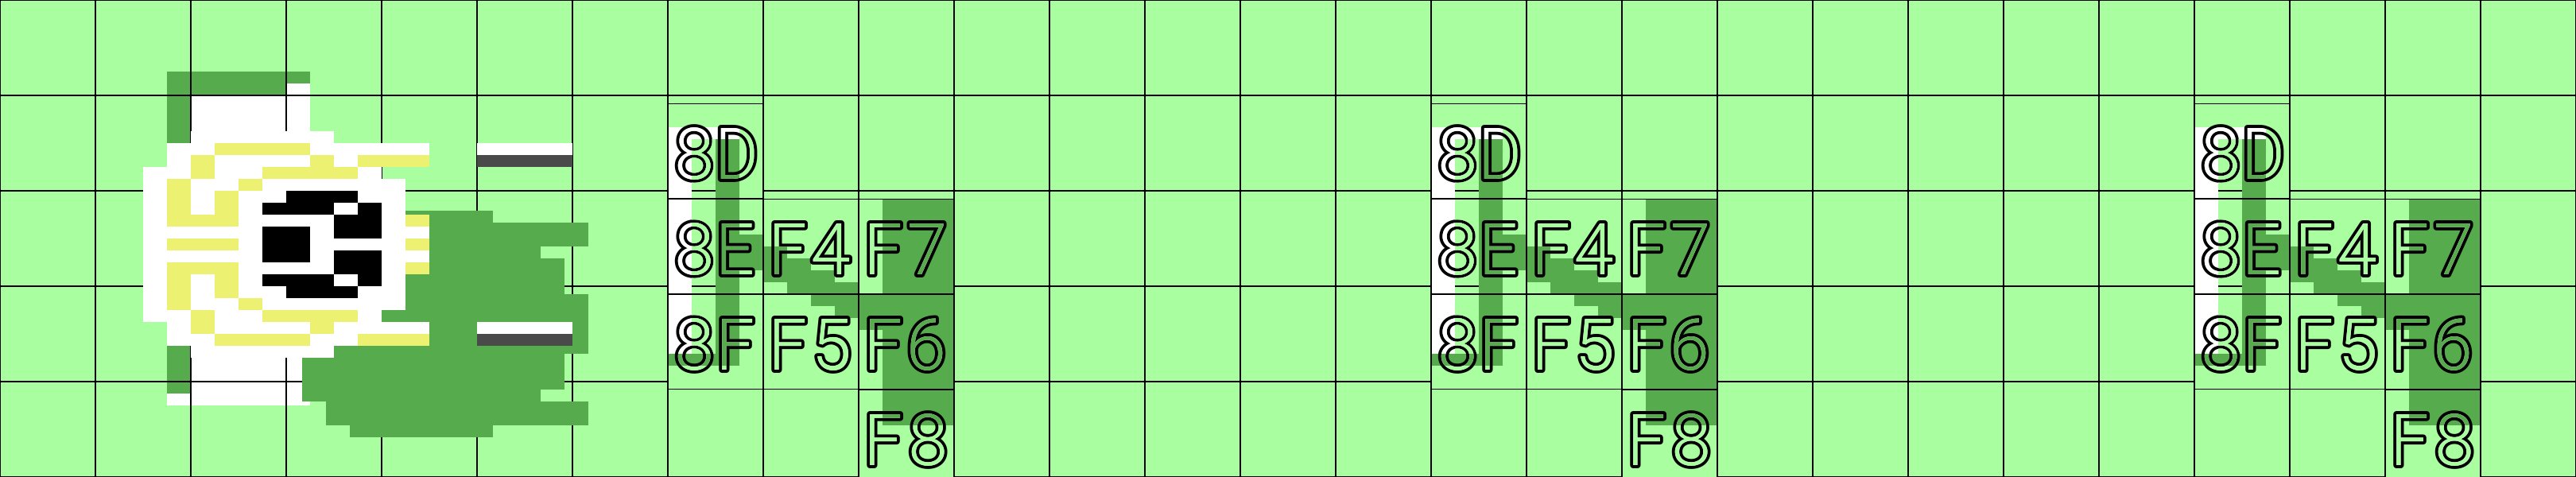

In [265]:
diagram = get_destroyed_surface_character_snippet(level=5, x_offset=cells(149), y_offset = 720, width=scale(216), height = scale(40))
shadow = make_shadow(manta.copy(), color=(0x56,0xac,0x4d,255))
manta_pos = (scale(12),scale(10))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)

bullet_x = cells(5)
bullet_pos = (bullet_x, scale(10) + 30)
diagram.paste(bullet, bullet_pos, mask=bullet)
bullet_pos = (bullet_x, scale(25) + 30)
diagram.paste(bullet, bullet_pos, mask=bullet)

diagram.save(f"bullets_player/level5_bullet_blocked_2.png")
diagram

### Draw Bullet Illustration with No Background

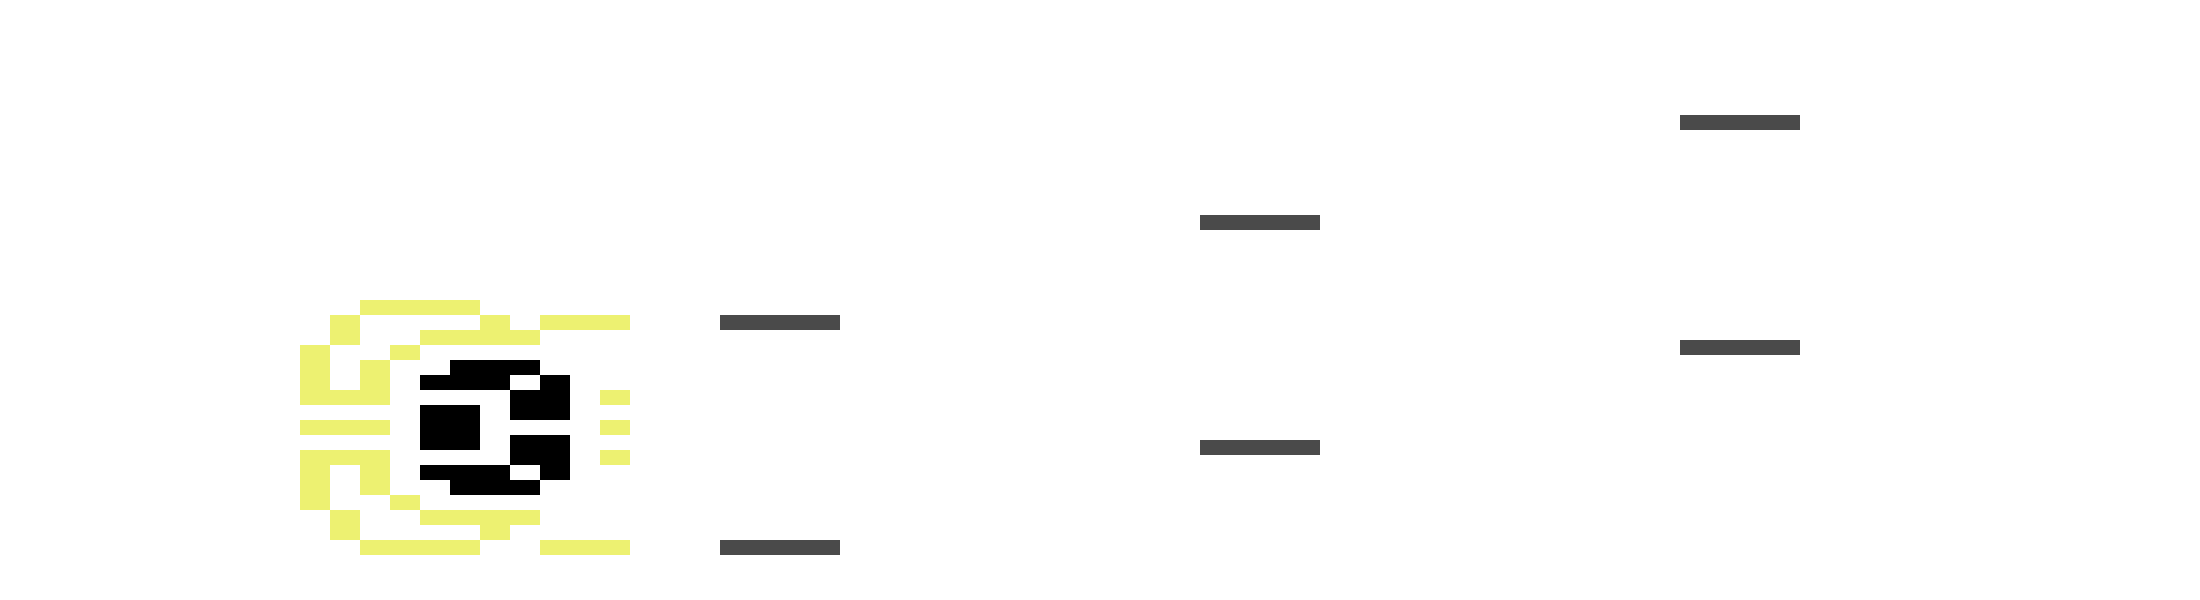

In [163]:
diagram = Image.new('RGBA', (2200,600))
manta_pos = (scale(18),scale(18))
diagram.paste(manta, manta_pos, mask=manta)

bullet_y = 30
for bullet_x in range(48, 64 + 76, 32):
    bullet_pos = (scale(bullet_x), scale(18) + bullet_y)
    diagram.paste(bullet, bullet_pos, mask=bullet)
    bullet_pos = (scale(bullet_x), scale(33) + bullet_y)
    diagram.paste(bullet, bullet_pos, mask=bullet)
    bullet_y -=100
diagram.save(f"bullets_player/bullets.png")
diagram

In [164]:
54, 58

(54, 58)

### Character Set Diagrams for Bullet

In [183]:
import re
from colors_map import *

def loadCharacterSet(charset_lines, ref_offset=0):
    character_set = {}
    charset_data = []
    char_ref = None
    for l in charset_lines:
        if "CHARACTER" in l:
            if charset_data:
                character_set[char_ref] = charset_data
            charset_data = []
            ref = int(l[61:63],16) + ref_offset
            char_ref = f"{ref:0{2}x}".upper()
             
        m = re.findall(r"[0-1]{8}",l)
        if not m:
            continue
        bits = m[0].strip()
        line_bits = []
        for i in range(0,7,2):
            bitpair = bits[i:i+2]
            line_bits += [bitpair]
            line_bits += [bitpair]
        charset_data += [line_bits]
    character_set[char_ref] = charset_data
    return character_set

charsets_file = "uridium/src/charset.asm"
input_file = open(charsets_file,'r')
charset_lines = input_file.readlines()
charset_lines = charset_lines[1439:]
base_character_set = loadCharacterSet(charset_lines)

character_files = [
    "uridium/src/surface1_charset.asm",
    "uridium/src/surface2_charset.asm",
    "uridium/src/surface3_charset.asm",
]
character_sets = []
for filename in character_files:
    charsets_file = filename
    input_file = open(charsets_file,'r')
    charset_lines = input_file.readlines()
    character_set = base_character_set | loadCharacterSet(charset_lines, ref_offset=0x80)
    character_sets += [character_set]


In [167]:
from colors_map import *
raw_level_color_schemes = """
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_YELLOW,M_ORANGE  ; Level 1
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_LTBLUE,M_BLUE    ; Level 4
        .BYTE M_GREEN,M_LTGREEN,M_ORANGE,M_LTBLUE,M_BLUE  ; Level 5
        .BYTE M_ORANGE,M_YELLOW,M_ORANGE,M_GRAY2,M_BLACK  ; Level 6
        .BYTE M_GRAY1,M_CYAN,M_LTGREEN,M_LTRED,M_RED      ; Level 7
        .BYTE M_BLACK,M_GRAY2,M_LTRED,M_LTBLUE,M_BLUE     ; Level 8
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_GRAY1,M_GRAY2,M_GRAY2,M_LTRED,M_RED       ; Level 10
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_BLUE,M_CYAN,M_ORANGE,M_GRAY2,M_GRAY1      ; Level 12
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_RED,M_LTRED,M_ORANGE,M_YELLOW,M_ORANGE    ; Level 15
"""
raw_level_color_schemes = [l[14:57].split(',') for l in raw_level_color_schemes.split('\n')][1:-1]
raw_level_color_schemes = [[x.strip() for x in l] for l in raw_level_color_schemes]
#raw_level_color_schemes = [v for l in raw_level_color_schemes for v in l]
#surface_ram = [temp_surface_ram[v:v+80] for v in range(0, len(temp_surface_ram), 80)]
#surface_ram = ["$"+x.upper() for x in flatten(surface_ram)]
level_colors = [None]
for l in raw_level_color_schemes:
    colors = (color_constants[l[1]], "c64_black", color_constants[l[0]], "c64_white")
    level_colors += [colors]

# The character sets each level uses.
level_charsets = [0,2,0,2,0,1,2,1,0,1,2,0,2,1,0,2]

level_names = [None, "Zinc","Lead","Copper","Silver","Iron","Gold","Platinum","Tungsten","Iridon","Kallisto","Tri-alloy","Quadmium","Ergonite","Galactium","Uridium"]

In [173]:
from PIL import Image, ImageColor
CHARACTER_COLS = 8
CHARACTER_ROWS = 8
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintCharacterDiagram(bit_array, colors, verticalExpand=False):
    multicol0, multicol1,color,color1 = colors
    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
        "00": color1,
    }
    
    image_width = CELL_WIDTH*CHARACTER_COLS
    image_height = CELL_HEIGHT*CHARACTER_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    draw = ImageDraw.Draw(img)

    fnt = ImageFont.truetype("RobotoMono-Light.ttf", 40)
    # Remember that each bitpair in the bit_array is duplicated.
    # e.g. 01 appears as 01,01 so that we can treat each element as
    # a single bit.
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            color_name = colormap[bit]
            pixel_color = ImageColor.getrgb(c64_to_rgb[color_name])
            X = x * CELL_WIDTH
            Y = y * CELL_HEIGHT
            draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), 
                           fill=pixel_color, outline="black")
            b = bit[(x%2)] # Get the correct side of the bitpair
            text_color = "black" if color_name in ["c64_white","c64_yellow","c64_cyan","c64_ltgreen"] else "white"
            draw.text((X+10, Y-8), b, font=fnt, fill=text_color)
    return img


In [177]:
byte_literals = """.BYTE
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
"""

def generateCharacterDiagram(character_image, character_name, level_name, level, colors, character_bytes):

    img = Image.new('RGBA', (540,350))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"{level_name.upper()}/CHAR/{character_name}"
    label_fnt_size = 19
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (5, (img.height - (label.height + 20))))

    # Color Label
    label_text = "BASE_COLOR: "
    label_fnt_size = 15
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * (label_fnt_size)
    txt = Image.new('RGBA', (txt_width-10, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[0]])
    draw.rectangle([(110,4), (120,14)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (30,330))

    # MultiCol0 Label
    label_text = "MULTI_COLOR0: "
    label_fnt_size = 15
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[1]])
    draw.rectangle([(130,4), (140,14)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (190,330))

    # MultiCol1 Label
    label_text = "MULTI_COLOR1: "
    label_fnt_size = 15
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[2]])
    draw.rectangle([(130,4), (140,14)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (370,330))


    # Sprite byte literals
    label_text = byte_literals
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(character_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (350,8))

    # Sprite bytes
    label_text = character_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(character_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (470,8))
    
    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)
    img.paste(character_image, (30,10))

    return img

def convertCharBitmapToByte(bits):
    bits = bits[::2] # every second element in the list
    bit_string = ''.join(bits)
    byte = ("00" + hex(int(bit_string,2))[2:])[-2:].upper()
    return byte


In [175]:
bullet_top = ['00', '00', '00', '00', '00', '00', '00', '00']
bullet_bottom = ['10', '10', '10', '10', '10', '10', '10', '10']


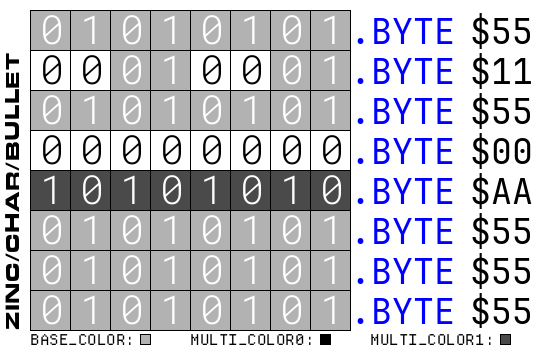

In [187]:
from PIL import ImageDraw, ImageFont

level = 1
level_name = level_names[level]
charset_ref = level_charsets[level]
colors = level_colors[level]
character_set = character_sets[charset_ref]
bit_array = character_set['54'].copy()
bit_array[3] = bullet_top
bit_array[4] = bullet_bottom
character_image = paintCharacterDiagram(bit_array, colors)
character_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array])
img = generateCharacterDiagram(character_image, 'BULLET', level_name, level, colors, character_bytes)

img.save(f"bullets_player/1_54_bullet.png")
img    

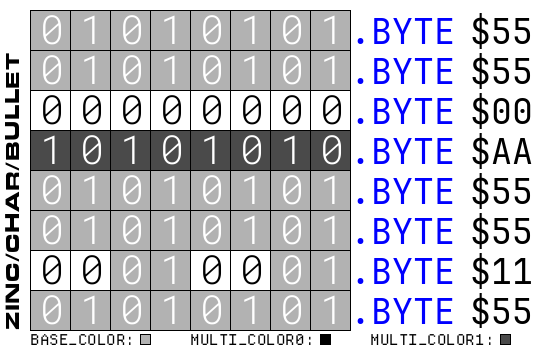

In [188]:
from PIL import ImageDraw, ImageFont

level = 1
level_name = level_names[level]
charset_ref = level_charsets[level]
colors = level_colors[level]
character_set = character_sets[charset_ref]
bit_array = character_set['58'].copy()
bit_array[2] = bullet_top
bit_array[3] = bullet_bottom
character_image = paintCharacterDiagram(bit_array, colors)
character_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array])
img = generateCharacterDiagram(character_image, 'BULLET', level_name, level, colors, character_bytes)

img.save(f"bullets_player/1_58_bullet.png")
img    

### Mini Diagrams for Destroyed Sections

In [198]:
def generateMiniCharDiagram(char_img, char_name):
    image_width = 10 + char_img.width + 10
    image_height = 10 + char_img.height + 70
    img = Image.new('RGBA', (image_width,image_height))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"{char_name.upper()}"
    label_fnt_size = 70
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    draw = ImageDraw.Draw(img)
    draw.text((10, char_img.height + 20), label_text, font=label_fnt, fill="black")

    img.paste(char_img, (18,10), mask=char_img)

    return img

In [195]:
!mkdir character_mini_diagrams

In [199]:
for level in range(1,16):
    charset_ref = level_charsets[level]
    character_set = character_sets[charset_ref]
    for char in character_set:
        char_img = Image.open(f"surface_characters/{level}_{char}.png")
        img = generateMiniCharDiagram(char_img, char)
        img.save(f"character_mini_diagrams/{level}_{char}.png")

## Scratchpad

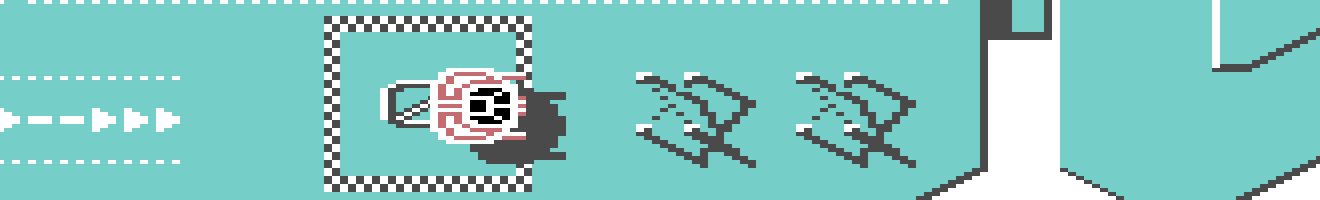

In [260]:
level = 7
diagram = get_surface_snippet(level=level, x_offset=2705, y_offset = 78, width=330, height = 50)
img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
manta = img.copy()
manta_pos = (215,32)
shadow_offset = (20,10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)
img = resize(diagram)
img.save("shadow/level7.png")
img

###  Masking the shadow so that it only falls on the dreadnought surface

charset/bitmap/background bits:

- 00 (d021, black) and 01 (d022, red) are always background (sprites are always 
  in front of it)
- 10 (d023, green) and 11 (colram, blue) are foreground. it will be in front of 
  sprites with the respective priority bit set.

sprite bits:

- 00/0  (transparent) (background or sprite with lower priority)
- 10/1  (sprite color, red/blue)
- 01    (d025, yellow) (Multicolor 1)
- 11    (d026, green) (Multicolor 2)

the priority can be made up by these two rules (this order!)

- starting from sprite with lowest number, find a non transparent (0/00) color.
  if none found, background (any) shows.
- if a non transparent sprite color was found in the previous step, and the 
  priority bit of the corresponding sprite is set, 10/11 background bits will
  show in front, else the sprite color shows.

the interesting case is when eg sprite 1 and sprite 0 overlap, and sprite 0 has
the priority bit set (and sprite 1 has not). in this case 10/11 background bits
show in front of whole sprite 0.

-- https://sourceforge.net/p/vice-emu/code/HEAD/tree/testprogs/VICII/spritepriorities/

https://sta.c64.org/cbm64mem.html

In [201]:
def make_mask(i):
    img = i.copy()
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] != 0:
            new_image.append((0xff, 0xff, 0xff))
        else:
            new_image.append((0,0,0))
    # update image data
    img.putdata(new_image)
    return img


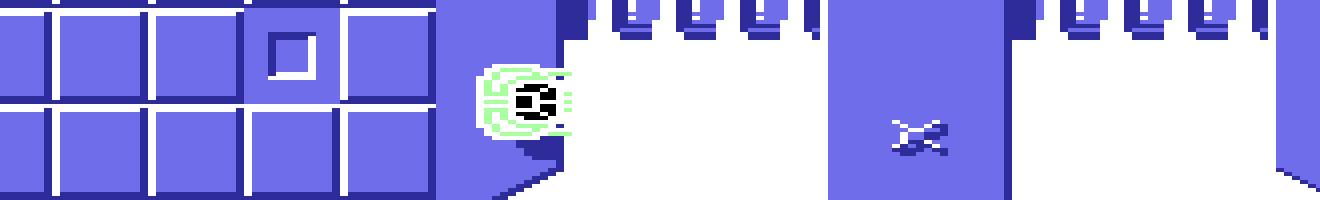

In [261]:
level = 9
diagram = get_surface_snippet(level=level, x_offset=2275, y_offset = 78, width=330, height = 50)
mask = make_mask(diagram).convert('L')
manta_pos = (238,30)
shadow_offset = (20,10)

img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
manta = img.copy()
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)
img = resize(diagram)
img.save("shadow/level9_clipped.png")
img

### Do the landing loop

In [346]:
from PIL import ImageDraw, ImageFont

def generateLandingDiagram():
    image_width = 1100
    image_height = 320
    img = Image.new('RGBA', (image_width,image_height))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"TRI-ALLOY/LANDING/SEQUENCE"
    label_fnt_size = 34
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    img.paste(txt, (5,5))

    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)

    x = 10
    for i in range(19,13,-1):
        limg = Image.open(f"shadow/landing_{i}.png")
        img.paste(limg, (x,40))
        x += limg.width

    x = 10
    for i in range(13,7,-1):
        limg = Image.open(f"shadow/landing_{i}.png")
        img.paste(limg, (x,170))
        x += limg.width

    return img

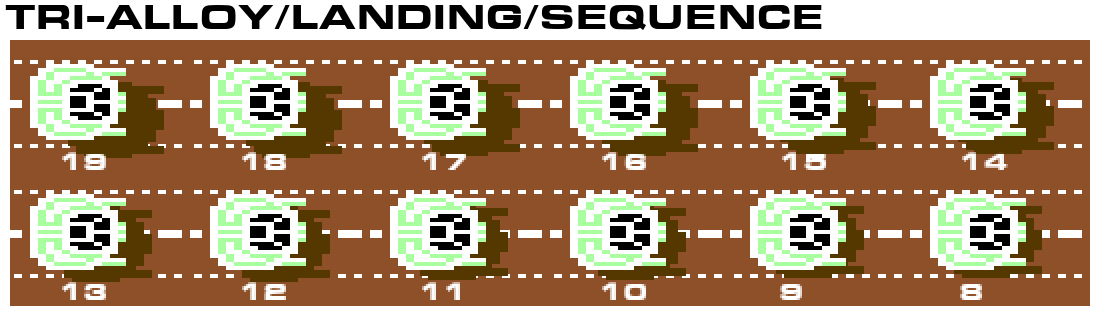

In [354]:
def textLabel(label_text, label_fnt_size = 40):
    # Sprite label
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = (len(label_text) * label_fnt_size)
    txt = Image.new('RGBA', (txt_width, label_fnt_size+10))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = (255,255,255,0))
    draw.text((0, 0), label_text, font=label_fnt, fill="white")
    return txt

for y in range(20,5,-1):
    level = 11
    diagram = get_surface_snippet(level=level, x_offset=2875, y_offset = 28, width=45, height = 34)
    manta_pos = (10,10)
    shadow_offset = (y,int(y/2))
    img = Image.open(f"manta_sprites/{level}_MANTA1.png")
    img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    manta = img.copy()
    shadow = make_shadow(manta.copy(),color=(0x55,0x38,0x00,255))
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)
    label = textLabel(str(y), label_fnt_size=12)
    diagram.paste(label,(25,56),mask=label)
    img = resize(diagram)
    img.save(f"shadow/landing_{y}.png")
landing_img = generateLandingDiagram()
landing_img.save(f"shadow/landing_sequence.png")
landing_img